# CDLE: Benchmark de Bibliotecas de Big Data em Python

Este notebook apresenta um estudo comparativo aprofundado entre três dos principais ecossistemas de manipulação de dados em Python: **Pandas**, **Dask** e **PySpark (Pandas-on-Spark/Koalas)**. O objetivo é analisar de forma rigorosa as diferenças de desempenho, comportamento de memória, escalabilidade e complexidade sintática ao realizar operações fundamentais em bases de dados de grande escala.

### Objetivos Académicos e Práticos:
1. **Identificar Gargalos de Desempenho (Bottlenecks):** Avaliar como cada biblioteca lida com operações intensivas de I/O, agregações e filtragens.
2. **Análise Sintática e de Paradigmas:** Confrontar a execução ansiosa (*eager*) com a execução preguiçosa (*lazy*).
3. **Casos de Uso Ideais:** Compreender em que cenários práticos cada ferramenta se destaca.
4. **Benchmarking em Ambiente GCP:** Executar as operações diretamente sobre o **Google Cloud Storage (GCS)** num cluster distribuído do **GCP Dataproc**, avaliando o comportamento sob restrições físicas de hardware.

### O Dataset:
Utilizaremos os dados públicos de viagens de táxi de Nova Iorque (**NYC Yellow Taxi Tripdata**), especificamente o mês de **Janeiro de 2009** no formato otimizado **Parquet**. Trata-se de um ficheiro de dimensão considerável (aproximadamente 14 milhões de registos), ideal para testar os limites de memória e processamento das ferramentas.

In [1]:
!pip install "modin[ray]"

In [2]:
# --- PATCH GLOBAL DE VISUALIZAÇÃO DE TABELAS ---
import pandas as pd
if not hasattr(pd.Index, '_format_flat'):
    pd.Index._format_flat = lambda self, *args, **kwargs: [str(x) for x in self]

try:
    import pyspark.pandas as ps
    if not hasattr(ps.Index, '_format_flat'):
        ps.Index._format_flat = lambda self, *args, **kwargs: [str(x) for x in self]
except Exception:
    pass
# -----------------------------------------------

import time
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# O caminho do ficheiro aponta diretamente para o Google Cloud Storage
file_path = 'gs://dataproc-staging-europe-southwest1-348488791616-f80l4tzf/notebooks/jupyter/yellow_tripdata_2009-01.parquet'

# Dicionários para guardar os tempos de execução
pandas_results = {}
dask_results = {}
pyspark_results = {}

/usr/lib/spark/python/pyspark/pandas/__init__.py:50: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(


---
## Parte 1: Pandas (O Padrão Eager e Single-Node)

O **Pandas** é a biblioteca de referência absoluta para ciência de dados em Python. No entanto, foi desenhado sob premissas específicas que determinam a sua viabilidade em Big Data:

### Características Principais:
* **Execução Eager (Ansiosa):** Cada linha de código é compilada e executada de imediato. Qualquer operação (leitura, filtro, agregação) gera imediatamente um novo objeto concreto na memória RAM.
* **Arquitetura Single-Node e Single-Threaded:** O Pandas opera estritamente num único computador e, devido ao *Global Interpreter Lock (GIL)* do Python, a maior parte das suas operações corre numa única thread (single-core).
* **Pegada de Memória (Memory Footprint):** Como regra geral, o Pandas requer entre **2 a 3 vezes mais memória RAM** do que o tamanho do dataset em disco para realizar operações de cópia, ordenação e alinhamento de índices. Isto torna-o altamente suscetível a falhas de *Out of Memory (OOM)* com datasets médios.

Nesta secção, medimos o desempenho básico do Pandas como a nossa linha de base (*baseline*) de comparação.

### 1.1 Read Data (Leitura do Parquet)

In [3]:
start = time.time()
df_pd = pd.read_parquet(file_path)
pandas_results['1. Read'] = time.time() - start

print(f"Tempo de Leitura Pandas: {pandas_results['1. Read']:.3f} s")
display(df_pd.head(5))

Tempo de Leitura Pandas: 5.718 s


,vendor_name,Trip_Pickup_DateTime,Trip_Dropoff_DateTime,Passenger_Count,Trip_Distance,Start_Lon,Start_Lat,Rate_Code,store_and_forward,End_Lon,End_Lat,Payment_Type,Fare_Amt,surcharge,mta_tax,Tip_Amt,Tolls_Amt,Total_Amt
0,VTS,2009-01-04 02:52:00,2009-01-04 03:02:00,1,2.63,-73.991957,40.721567,NaN,NaN,-73.993803,40.695922,CASH,8.9,0.5,NaN,0.00,0.0,9.40
1,VTS,2009-01-04 03:31:00,2009-01-04 03:38:00,3,4.55,-73.982102,40.736290,NaN,NaN,-73.955850,40.768030,Credit,12.1,0.5,NaN,2.00,0.0,14.60
2,VTS,2009-01-03 15:43:00,2009-01-03 15:57:00,5,10.35,-74.002587,40.739748,NaN,NaN,-73.869983,40.770225,Credit,23.7,0.0,NaN,4.74,0.0,28.44
3,DDS,2009-01-01 20:52:58,2009-01-01 21:14:00,1,5.00,-73.974267,40.790955,NaN,NaN,-73.996558,40.731849,CREDIT,14.9,0.5,NaN,3.05,0.0,18.45
4,DDS,2009-01-24 16:18:23,2009-01-24 16:24:56,1,0.40,-74.001580,40.719382,NaN,NaN,-74.008378,40.720350,CASH,3.7,0.0,NaN,0.00,0.0,3.70


### 1.2 Count (Contagem de Linhas)

In [4]:
start = time.time()
total_rows_pd = len(df_pd)
pandas_results['2. Count'] = time.time() - start

print(f"Tempo de Contagem Pandas: {pandas_results['2. Count']:.3f} s (Total de viagens: {total_rows_pd})")

Tempo de Contagem Pandas: 0.000 s (Total de viagens: 14092413)


### 1.3 Value Counts (Frequências)
Contar quantas viagens foram processadas por cada fornecedor (`vendor_name`).

In [5]:
start = time.time()
vc_pd = df_pd['vendor_name'].value_counts()
pandas_results['3. Value Counts'] = time.time() - start

print(f"Tempo de Value Counts Pandas: {pandas_results['3. Value Counts']:.3f} s")
display(vc_pd.to_frame())

Tempo de Value Counts Pandas: 0.454 s


,count
vendor_name,
VTS,6848556
CMT,6380959
DDS,862898


### 1.4 GroupBy (Agrupamento e Agregação)
Agrupar pelo tipo de pagamento (`Payment_Type`) e calcular a tarifa média.

In [6]:
start = time.time()
gb_pd = df_pd.groupby('Payment_Type')['Fare_Amt'].mean()
pandas_results['4. GroupBy'] = time.time() - start

print(f"Tempo de GroupBy Pandas: {pandas_results['4. GroupBy']:.3f} s")
display(gb_pd.to_frame())

Tempo de GroupBy Pandas: 0.600 s


,Fare_Amt
Payment_Type,
CASH,8.911917
CREDIT,11.929002
Cash,9.023633
Credit,11.428076
Dispute,11.608134
No Charge,10.216337


### 1.5 Add Column (Mutação de Dados)
Criar uma nova coluna `Total_Calculated` adicionando a tarifa, gorjeta e portagens.

In [7]:
start = time.time()
df_pd['Total_Calculated'] = df_pd['Fare_Amt'] + df_pd['Tip_Amt'] + df_pd['Tolls_Amt']
pandas_results['5. Add Column'] = time.time() - start

print(f"Tempo de Adição de Coluna Pandas: {pandas_results['5. Add Column']:.3f} s")
display(df_pd[['Fare_Amt', 'Tip_Amt', 'Tolls_Amt', 'Total_Calculated']].head(2))

Tempo de Adição de Coluna Pandas: 0.064 s


,Fare_Amt,Tip_Amt,Tolls_Amt,Total_Calculated
0,8.9,0.0,0.0,8.9
1,12.1,2.0,0.0,14.1


### 1.6 Filter (Filtragem)
Encontrar todas as viagens que custaram estritamente mais de 10 dólares.

In [8]:
start = time.time()
filtered_pd = df_pd[df_pd['Fare_Amt'] > 10]
pandas_results['6. Filter'] = time.time() - start

print(f"Tempo de Filtragem Pandas: {pandas_results['6. Filter']:.3f} s (Total filtrado: {len(filtered_pd)})")

Tempo de Filtragem Pandas: 0.590 s (Total filtrado: 4097866)


Libertar memória do Pandas antes de iniciar o Dask

In [9]:
import gc
del df_pd, filtered_pd
gc.collect()

17

---
## Parte 2: Dask (Computação Paralela e Out-of-Core baseada em Grafos)

O **Dask** é uma biblioteca de computação flexível e paralela que expande o ecossistema científico do Python (Pandas, NumPy, Scikit-Learn) para sistemas distribuídos e processamento que excede a memória RAM disponível (*Out-of-Core*).

### Como Funciona o Dask:
* **Arquitetura Particionada:** Um `dask.dataframe` é composto por múltiplos pequenos DataFrames do Pandas, divididos por partições de linhas. O Dask gere a execução de operações sobre cada partição de forma coordenada.
* **Execução Lazy (Preguiçosa):** Ao contrário do Pandas, o Dask não executa as operações imediatamente. Em vez disso, ele constrói um **Grafo Acíclico Dirigido (DAG)** que mapeia todas as tarefas necessárias. A computação real só é disparada quando invocamos uma ação explícita, como `.compute()`, `.head()` ou `len()`.
* **Otimização de Grafo:** O motor do Dask analisa o DAG para fundir operações (ex: ler o ficheiro e aplicar um filtro na mesma passagem), evitando leituras desnecessárias de colunas e poupando memória.
* **Gestão de Memória Estável:** Permite processar datasets muito maiores do que a memória RAM física através do processamento sequencial de partições e descarte automático de dados intermédios (*garbage collection*).

*(Nota: Para garantir estabilidade no nó Master do Dataproc de 16GB, configurámos o agendador do Dask para modo síncrono/sequencial, garantindo que o processamento de partições não gere picos acumulados de RAM)*

### 2.1 Read Data (Leitura do Parquet)

In [10]:
# Monkey-patch para resolver incompatibilidade entre Dask antigo e Python 3.11+
try:
    import dask.utils
    original_derived_from = dask.utils.derived_from
    def safe_derived_from(*args, **kwargs):
        decorator = original_derived_from(*args, **kwargs)
        def safe_decorator(func):
            try:
                return decorator(func)
            except Exception:
                return func
        return safe_decorator
    dask.utils.derived_from = safe_derived_from
    import dask
    dask.config.set(scheduler='synchronous') # Execução sequencial para evitar OOM no Master node
except Exception as e:
    print(f"Aviso ao aplicar patch do Dask: {e}")

import dask.dataframe as dd

start = time.time()
df_dd = dd.read_parquet(file_path)
dask_results['1. Read'] = time.time() - start

print(f"Tempo de Leitura Dask: {dask_results['1. Read']:.3f} s (Note-se que a avaliação é Lazy)")

Tempo de Leitura Dask: 0.466 s (Note-se que a avaliação é Lazy)


### 2.2 Count (Conta as linhas)

In [11]:
start = time.time()
total_rows_dd = len(df_dd)
dask_results['2. Count'] = time.time() - start

print(f"Tempo de Contagem Dask: {dask_results['2. Count']:.3f} s")

Tempo de Contagem Dask: 0.329 s


### 2.3 Value Counts (Frequências)
Contar quantas viagens foram processadas por cada fornecedor (`vendor_name`).

In [12]:
start = time.time()
# Temos de forçar o cálculo da distribuição com o .compute()
vc_dd = df_dd['vendor_name'].value_counts().compute()
dask_results['3. Value Counts'] = time.time() - start

print(f"Tempo de Value Counts Dask: {dask_results['3. Value Counts']:.3f} s")
display(vc_dd.to_frame())

Tempo de Value Counts Dask: 0.459 s


,count
vendor_name,
VTS,6848556
CMT,6380959
DDS,862898


### 2.4 GroupBy (Agrupamento e Agregação)
Agrupar pelo tipo de pagamento (`Payment_Type`) e calcular a tarifa média.

In [13]:
start = time.time()
gb_dd = df_dd.groupby('Payment_Type')['Fare_Amt'].mean().compute()
dask_results['4. GroupBy'] = time.time() - start

print(f"Tempo de GroupBy Dask: {dask_results['4. GroupBy']:.3f} s")
display(gb_dd.to_frame())

Tempo de GroupBy Dask: 1.329 s


,Fare_Amt
Payment_Type,
CASH,8.911917
CREDIT,11.929002
Cash,9.023633
Credit,11.428076
Dispute,11.608134
No Charge,10.216337


### 2.5 Add Column (Mutação de Dados)
Criar uma nova coluna `Total_Calculated` adicionando a tarifa, gorjeta e portagens.

In [14]:
start = time.time()
df_dd['Total_Calculated'] = df_dd['Fare_Amt'] + df_dd['Tip_Amt'] + df_dd['Tolls_Amt']
preview_dd = df_dd['Total_Calculated'].head() # Usamos o head() para simular o trigger da ação
dask_results['5. Add Column'] = time.time() - start

print(f"Tempo de Adição de Coluna Dask: {dask_results['5. Add Column']:.3f} s")

Tempo de Adição de Coluna Dask: 9.485 s


### 2.6 Filter (Filtragem)
Encontrar todas as viagens que custaram estritamente mais de 10 dólares.

In [15]:
start = time.time()
filtered_dd = df_dd[df_dd['Fare_Amt'] > 10].head()
dask_results['6. Filter'] = time.time() - start

print(f"Tempo de Filtragem Dask: {dask_results['6. Filter']:.3f} s")

Tempo de Filtragem Dask: 9.836 s


Libertar memória do Dask antes de iniciar o PySpark, para não haver crash do clutcher.

In [16]:
import gc
del df_dd, filtered_dd
gc.collect()

64

---
## Parte 3: PySpark (Processamento Massivo Distribuído - Spark Engine)

O **Apache Spark** é a plataforma de computação distribuída padrão da indústria para processamento de Big Data. O **PySpark** fornece a interface Python para o motor do Spark, e através da API **Pandas-on-Spark** (antigo Koalas), permite executar código com sintaxe Pandas diretamente sobre a arquitetura do Spark.

### O Motor do PySpark:
* **Execução Distribuída Massiva (Master-Worker):** O Spark foi desenhado desde a raiz para funcionar em clusters (como o GCP Dataproc). O nó Master planeia a execução e distribui as partições de dados para múltiplos nós Workers, que processam a informação em paralelo na JVM (Java Virtual Machine).
* **Lazy Evaluation Avançada (Catalyst Optimizer):** Tal como o Dask, o Spark é lazy. No entanto, ele possui o otimizador *Catalyst*, que traduz o código em planos de execução lógicos e físicos altamente otimizados antes de iniciar qualquer computação.
* **Resiliência e Tolerância a Falhas:** Os dados são mantidos em estruturas resilientes. Se um nó worker falhar a meio de uma computação, o Spark reconstrói automaticamente a partição perdida a partir do grafo de linhagem (*lineage graph*).
* **API Pandas-on-Spark (`pyspark.pandas`):** Permite que cientistas de dados familiarizados com o Pandas escalem os seus códigos para petabytes de dados sem reescrever a lógica de manipulação.

### 3.1 Read Data (Leitura do Parquet)

In [17]:
import os
os.environ['PYARROW_IGNORE_TIMEZONE'] = '1'
from pyspark.sql import SparkSession
import pyspark.pandas as ps

# Inicializar o Spark (no Dataproc, ele utiliza o YARN por defeito)
spark = SparkSession.builder \
    .appName('CDLE-Benchmark') \
    .config('spark.sql.ansi.enabled', 'false') \
    .getOrCreate()

start = time.time()
df_ps = ps.read_parquet(file_path)
pyspark_results['1. Read'] = time.time() - start

print(f"Tempo de Leitura PySpark: {pyspark_results['1. Read']:.3f} s")
display(df_ps.head(2))

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/25 17:05:41 INFO SparkEnv: Registering MapOutputTracker
26/05/25 17:05:41 INFO SparkEnv: Registering BlockManagerMaster
26/05/25 17:05:41 INFO SparkEnv: Registering BlockManagerMasterHeartbeat
26/05/25 17:05:41 INFO SparkEnv: Registering OutputCommitCoordinator
/usr/lib/spark/python/pyspark/pandas/utils.py:1016: PandasAPIOnSparkAdviceWarning: If `index_col` is not specified for `read_parquet`, the default index is attached which can cause additional overhead.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


Tempo de Leitura PySpark: 6.795 s


,vendor_name,Trip_Pickup_DateTime,Trip_Dropoff_DateTime,Passenger_Count,Trip_Distance,Start_Lon,Start_Lat,Rate_Code,store_and_forward,End_Lon,End_Lat,Payment_Type,Fare_Amt,surcharge,mta_tax,Tip_Amt,Tolls_Amt,Total_Amt
0,VTS,2009-01-04 02:52:00,2009-01-04 03:02:00,1,2.63,-73.991957,40.721567,NaN,NaN,-73.993803,40.695922,CASH,8.9,0.5,NaN,0.0,0.0,9.4
1,VTS,2009-01-04 03:31:00,2009-01-04 03:38:00,3,4.55,-73.982102,40.736290,NaN,NaN,-73.955850,40.768030,Credit,12.1,0.5,NaN,2.0,0.0,14.6


### 3.2 Count (Conta as linhas)

In [18]:
start = time.time()
total_rows_ps = len(df_ps)
pyspark_results['2. Count'] = time.time() - start

print(f"Tempo de Contagem PySpark: {pyspark_results['2. Count']:.3f} s")

Tempo de Contagem PySpark: 1.009 s


### 3.3 Value Counts (Frequências)
Contar quantas viagens foram processadas por cada fornecedor (`vendor_name`).

In [19]:
start = time.time()
vc_ps = df_ps['vendor_name'].value_counts()
pyspark_results['3. Value Counts'] = time.time() - start

print(f"Tempo de Value Counts PySpark: {pyspark_results['3. Value Counts']:.3f} s")
display(vc_ps.to_frame())

Tempo de Value Counts PySpark: 0.084 s


/usr/lib/spark/python/pyspark/pandas/base.py:1437: FutureWarning: The resulting Series will have a fixed name of 'count' from 4.0.0.
  warnings.warn(


,vendor_name
VTS,6848556
CMT,6380959
DDS,862898


### 3.4 GroupBy (Agrupamento e Agregação)
Agrupar pelo tipo de pagamento (`Payment_Type`) e calcular a tarifa média.

In [20]:
start = time.time()
gb_ps = df_ps.groupby('Payment_Type')['Fare_Amt'].mean()
pyspark_results['4. GroupBy'] = time.time() - start

print(f"Tempo de GroupBy PySpark: {pyspark_results['4. GroupBy']:.3f} s")
display(gb_ps.to_frame())

/usr/lib/spark/python/pyspark/pandas/groupby.py:649: FutureWarning: Default value of `numeric_only` will be changed to `False` instead of `True` in 4.0.0.
  warnings.warn(


Tempo de GroupBy PySpark: 0.153 s


,Fare_Amt
Payment_Type,
CREDIT,11.929002
Cash,9.023633
Dispute,11.608134
CASH,8.911917
No Charge,10.216337
Credit,11.428076


### 3.5 Add Column (Mutação de Dados)
Criar uma nova coluna `Total_Calculated` adicionando a tarifa, gorjeta e portagens.

In [21]:
start = time.time()
df_ps['Total_Calculated'] = df_ps['Fare_Amt'] + df_ps['Tip_Amt'] + df_ps['Tolls_Amt']
pyspark_results['5. Add Column'] = time.time() - start

print(f"Tempo de Adição de Coluna PySpark: {pyspark_results['5. Add Column']:.3f} s")

Tempo de Adição de Coluna PySpark: 0.066 s


### 3.6 Filter (Filtragem)
Encontrar todas as viagens que custaram estritamente mais de 10 dólares.

In [22]:
start = time.time()
filtered_ps = df_ps[df_ps['Fare_Amt'] > 10].head()
pyspark_results['6. Filter'] = time.time() - start

print(f"Tempo de Filtragem PySpark: {pyspark_results['6. Filter']:.3f} s")

# Parar SparkSession e libertar memória para o gráfico final
import gc
spark.stop()
del df_ps, filtered_ps
gc.collect()

Tempo de Filtragem PySpark: 0.173 s


1141

---
## Parte 5: Modin
Nesta parte do projeto, vamos implementar os mesmos parametros, mas com 

O modin é uma biblioteca de código aberto em Python projetada para acelarar e dimensionar fluxos de trabalho da biblioteca Pandas. Esta biblioteca funciona como um substituto direto do Pandas, sendo asim a sintaxe semelhante à do pandas, mas por baixo do "capô" ele distribui as operações pelas CPUs da máquina, usando do Dask ou Ray.

### 5.1 Read Data

In [23]:
# 1. Definir o Dask como motor do Modin (para evitar picos de memória do Ray)
import os
os.environ["MODIN_ENGINE"] = "python"

# 2. Patch de compatibilidade Modin e Pandas 2.1.4
import sys
import pandas as pd
try:
    import pandas.core.arrays.arrow
except ImportError:
    import types
    sys.modules['pandas.core.arrays.arrow'] = types.ModuleType('pandas.core.arrays.arrow')
    import pandas.core.arrays.arrow

if not hasattr(pandas.core.arrays.arrow, 'ListAccessor'):
    class DummyListAccessor: pass
    pandas.core.arrays.arrow.ListAccessor = DummyListAccessor

if not hasattr(pandas.core.arrays.arrow, 'StructAccessor'):
    class DummyStructAccessor: pass
    pandas.core.arrays.arrow.StructAccessor = DummyStructAccessor

# -----------------------------------------------------

# --- PATCH DE COMPATIBILIDADE PANDAS 2.1.4 E MODIN ---
import sys
import pandas as pd
try:
    import pandas.core.arrays.arrow
except ImportError:
    import types
    sys.modules['pandas.core.arrays.arrow'] = types.ModuleType('pandas.core.arrays.arrow')
    import pandas.core.arrays.arrow
if not hasattr(pandas.core.arrays.arrow, 'ListAccessor'):
    class DummyListAccessor: pass
    pandas.core.arrays.arrow.ListAccessor = DummyListAccessor

if not hasattr(pandas.core.arrays.arrow, 'StructAccessor'):
    class DummyStructAccessor: pass
    pandas.core.arrays.arrow.StructAccessor = DummyStructAccessor

import time
import modin.pandas as mpd
from IPython.display import display

# Dicionário para armazenar os tempos de execução do Modin
modin_results = {}

start = time.time()
df_mod = mpd.read_parquet(file_path)
modin_results['1. Read'] = time.time() - start

print(f"Tempo de Leitura Modin: {modin_results['1. Read']:.3f} s")
display(df_mod.head(2))

Please refer to https://modin.readthedocs.io/en/stable/supported_apis/defaulting_to_pandas.html for explanation.


Tempo de Leitura Modin: 7.968 s


,vendor_name,Trip_Pickup_DateTime,Trip_Dropoff_DateTime,Passenger_Count,Trip_Distance,Start_Lon,Start_Lat,Rate_Code,store_and_forward,End_Lon,End_Lat,Payment_Type,Fare_Amt,surcharge,mta_tax,Tip_Amt,Tolls_Amt,Total_Amt
0,VTS,2009-01-04 02:52:00,2009-01-04 03:02:00,1,2.63,-73.991957,40.721567,NaN,NaN,-73.993803,40.695922,CASH,8.9,0.5,NaN,0.0,0.0,9.4
1,VTS,2009-01-04 03:31:00,2009-01-04 03:38:00,3,4.55,-73.982102,40.736290,NaN,NaN,-73.955850,40.768030,Credit,12.1,0.5,NaN,2.0,0.0,14.6


### 5.2 Count (Conta as linhas)

In [24]:
start = time.time()
total_rows_mod = len(df_mod)
modin_results['2. Count'] = time.time() - start

print(f"Tempo de Contagem Modin: {modin_results['2. Count']:.3f}s (Total de viagens: {total_rows_mod})")

Tempo de Contagem Modin: 0.000s (Total de viagens: 14092413)


### 5.3 Value Counts (Frequências)
Contar quantas viagens foram processadas por cada fornecedor (`vendor_name`).

In [25]:
start = time.time()
val_mod = df_mod['vendor_name'].value_counts()
modin_results['3. Value Counts'] = time.time() - start

print(f"Tempo de Value Counts com Modin: {modin_results['3. Value Counts']:.3f}s")
display(val_mod.to_frame())

the groupby keys will be sorted anyway, although the 'sort=False' was passed. See the following issue for more details: https://github.com/modin-project/modin/issues/3571.


Tempo de Value Counts com Modin: 3.223s


,count
vendor_name,
VTS,6848556
CMT,6380959
DDS,862898


### 5.4 GroupBy (Agrupamento e Agregação)
Agrupar pelo tipo de pagamento (`Payment_Type`) e calcular a tarifa média.

In [26]:
start = time.time()
gb_mod = df_mod.groupby('Payment_Type')['Fare_Amt'].mean()
modin_results['4. GroupBy'] = time.time() - start

print(f"Tempo de GroupBy com Modin: {modin_results['4. GroupBy']:.3f}s")
display(gb_mod.to_frame())

Tempo de GroupBy com Modin: 5.393s


,Fare_Amt
Payment_Type,
CASH,8.911917
CREDIT,11.929002
Cash,9.023633
Credit,11.428076
Dispute,11.608134
No Charge,10.216337


### 5.5 Add Column (Mutação de Dados)
Criar uma nova coluna `Total_Calculated` adicionando a tarifa, gorjeta e portagens.

In [27]:
start = time.time()
df_mod['Total_Calculated'] = df_mod['Fare_Amt'] + df_mod['Tip_Amt'] + df_mod['Tolls_Amt']
modin_results['5. Add Column'] = time.time() - start

print(f"Tempo de Adição de coluna com Modin:{modin_results['5. Add Column']:.3f}s")
display(df_mod[['Fare_Amt', 'Tip_Amt', 'Tolls_Amt', 'Total_Calculated']].head(2))

Tempo de Adição de coluna com Modin:10.433s


,Fare_Amt,Tip_Amt,Tolls_Amt,Total_Calculated
0,8.9,0.0,0.0,8.9
1,12.1,2.0,0.0,14.1


### 5.6 Filter (Filtragem)
Encontrar todas as viagens que custaram estritamente mais de 10 dólares.

In [28]:
start = time.time()
filtered_mod = df_mod[df_mod['Fare_Amt'] > 10].head()
modin_results['6. Filter'] = time.time() - start

print(f"Tempo de filtragem com Modin: {modin_results['6. Filter']:.3f}s")

Tempo de filtragem com Modin: 7.674s


Para limpar a memória ativa do modin, para evitar o crash dos clusters

In [29]:
import gc
del df_mod, filtered_mod
gc.collect()

1764

---
## Parte 6: Joblib

O Joblib é uma biblioteca de paralelização genérica baseada em subprocessos (multiprocessing). Como o Joblib não tem uma estrutura de dados própria, o padrão seria dividir o dataframe em fatias/chunks e processá-las em paralelo no Joblib, e por fim combinar os resultados parciais.

In [30]:
import time
import pandas as pd
import numpy as np
from joblib import Parallel, delayed
from IPython.display import display

joblib_results = {}

### 6.1 Read Data

In [31]:
start = time.time()
df_pd_job = pd.read_parquet(file_path)
joblib_results['1. Read'] = time.time() - start

print(f"Tempo de Leitura com Joblib: {joblib_results['1. Read']:.3f} s")
display(df_pd_job.head(2))

Tempo de Leitura com Joblib: 5.757 s


,vendor_name,Trip_Pickup_DateTime,Trip_Dropoff_DateTime,Passenger_Count,Trip_Distance,Start_Lon,Start_Lat,Rate_Code,store_and_forward,End_Lon,End_Lat,Payment_Type,Fare_Amt,surcharge,mta_tax,Tip_Amt,Tolls_Amt,Total_Amt
0,VTS,2009-01-04 02:52:00,2009-01-04 03:02:00,1,2.63,-73.991957,40.721567,NaN,NaN,-73.993803,40.695922,CASH,8.9,0.5,NaN,0.0,0.0,9.4
1,VTS,2009-01-04 03:31:00,2009-01-04 03:38:00,3,4.55,-73.982102,40.736290,NaN,NaN,-73.955850,40.768030,Credit,12.1,0.5,NaN,2.0,0.0,14.6


### 6.2 Count

In [32]:
start = time.time()
chunks = np.array_split(df_pd_job, 4)
results = Parallel(n_jobs = 4)(delayed(len)(chunk) for chunk in chunks)
total_rows_job = sum(results)
joblib_results['2. Count'] = time.time() - start

print(f"Tempo de Contagem com Joblib: {joblib_results['2. Count']:.3f} s")

Tempo de Contagem com Joblib: 8.504 s


### 6.3 Value Counts (Frequências)
Contar quantas viagens foram processadas por cada fornecedor (`vendor_name`).

In [33]:
def val_chunk(chunk):
    return chunk['vendor_name'].value_counts()

start = time.time()
chunks = np.array_split(df_pd_job, 4)
results = Parallel(n_jobs = 4)(delayed(val_chunk)(chunk) for chunk in chunks)
vc_job = pd.concat(results).groupby(level=0).sum()
joblib_results['3. Value Counts'] = time.time() - start

print(f"Tempo de Value Counts com Joblib: {joblib_results['3. Value Counts']:.3f} s")
display(vc_job.to_frame())

Tempo de Value Counts com Joblib: 8.238 s


,count
vendor_name,
CMT,6380959
DDS,862898
VTS,6848556


### 6.4 GroupBy
Para calcular a média global corretamente em paralelo, precisamos de obter a soma e o count parciais

In [34]:
def gb_chunk(chunk):
    return chunk.groupby('Payment_Type')['Fare_Amt'].agg(['sum', 'count'])

chunks = np.array_split(df_pd_job, 4)
results = Parallel(n_jobs=4)(delayed(gb_chunk)(chunk) for chunk in chunks)
combined = pd.concat(results).groupby('Payment_Type').sum()
gb_job = combined['sum'] / combined['count']
joblib_results['4. GroupBy'] = time.time() - start

print(f"Tempo de GroupBy Joblib: {joblib_results['4. GroupBy']:.3f} s")
display(gb_job.to_frame())


Tempo de GroupBy Joblib: 16.549 s


,0
Payment_Type,
CASH,8.911917
CREDIT,11.929002
Cash,9.023633
Credit,11.428076
Dispute,11.608134
No Charge,10.216337


### 6.5 Add Column (Mutação de Dados)
Criar uma nova coluna `Total_Calculated` adicionando a tarifa, gorjeta e portagens.

In [35]:
def add_col_chunk(chunk):
    chunk['Total_Calculated'] = chunk['Fare_Amt'] + chunk['Tip_Amt'] + chunk['Tolls_Amt']
    return chunk

start = time.time()
chunks = np.array_split(df_pd_job, 4)
results = Parallel(n_jobs=4)(delayed(add_col_chunk)(chunk) for chunk in chunks)

df_pd_job = pd.concat(results)
joblib_results['5. Add Column'] = time.time() - start

print(f"Tempo de Adição de Coluna com Joblib: {joblib_results['5. Add Column']:.3f} s")
display(df_pd_job[['Fare_Amt', 'Tip_Amt', 'Tolls_Amt', 'Total_Calculated']].head(2))

Tempo de Adição de Coluna com Joblib: 15.255 s


,Fare_Amt,Tip_Amt,Tolls_Amt,Total_Calculated
0,8.9,0.0,0.0,8.9
1,12.1,2.0,0.0,14.1


### 6.6 Filter (Filtragem)
Encontrar todas as viagens que custaram estritamente mais de 10 dólares.

In [36]:
def filter_chunk(chunk):
    return chunk[chunk['Fare_Amt'] > 10]

start = time.time()
chunks = np.array_split(df_pd_job, 4)
results = Parallel(n_jobs=4)(delayed(filter_chunk)(chunk) for chunk in chunks)
filtered_job = pd.concat(results)
joblib_results['6. Filter'] = time.time() - start

print(f"Tempo de Filtragem com Joblib: {joblib_results['6. Filter']:.3f} s")

Tempo de Filtragem com Joblib: 12.280 s


Para limpar a memória ativa do joblib, para não causar um crash dos clusters.

In [37]:
import gc
del df_pd_job, filtered_job
gc.collect()

81

---
## Parte 7: Análise Comparativa e Resumo Gráfico de Performance

Reunimos nesta secção final os tempos de execução guardados em todas as secções anteriores. O código abaixo analisa dinamicamente quais as bibliotecas que correram com sucesso e constrói uma tabela resumo consolidada e um gráfico de barras estilizado.

   RESUMO COMPARATIVO DOS TEMPOS DE EXECUÇÃO (SEGUNDOS)   


,Pandas (s),Dask (s),PySpark (s),Modin (s),Joblib (s)
1. Read,5.718,0.466,6.795,7.968,5.757
2. Count,0.000,0.329,1.009,0.000,8.504
3. Value Counts,0.454,0.459,0.084,3.223,8.238
4. GroupBy,0.600,1.329,0.153,5.393,16.549
5. Add Column,0.064,9.485,0.066,10.433,15.255
6. Filter,0.590,9.836,0.173,7.674,12.280


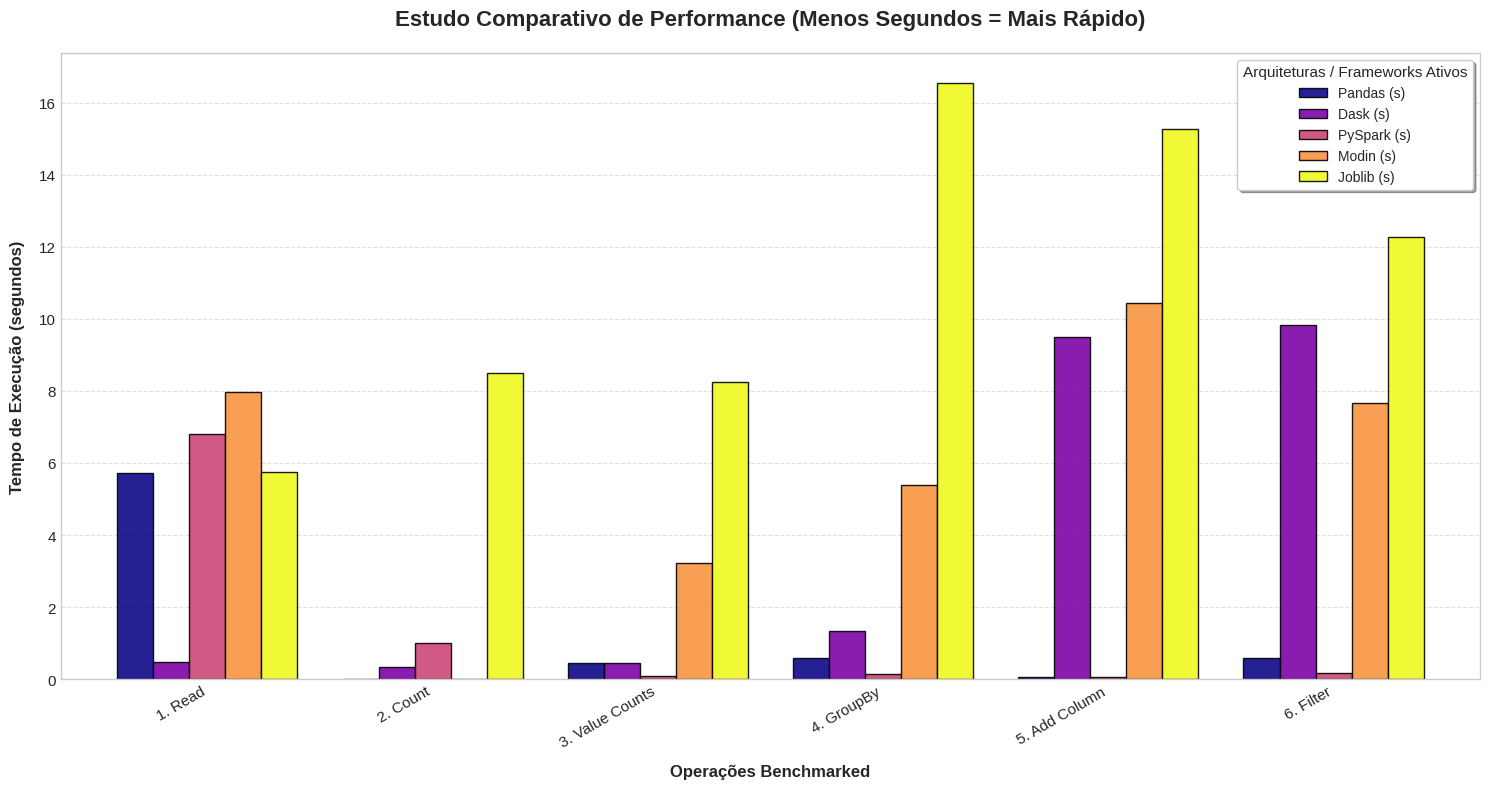

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import os

active_runs = {}

try:
    if 'pandas_results' in locals() and pandas_results:
        active_runs['Pandas (s)'] = pandas_results
except NameError: pass

try:
    if 'dask_results' in locals() and dask_results:
        active_runs['Dask (s)'] = dask_results
except NameError: pass

try:
    if 'pyspark_results' in locals() and pyspark_results:
        active_runs['PySpark (s)'] = pyspark_results
except NameError: pass

try:
    if 'modin_results' in locals() and modin_results:
        active_runs['Modin (s)'] = modin_results
except NameError: pass

try:
    if 'joblib_results' in locals() and joblib_results:
        active_runs['Joblib (s)'] = joblib_results
except NameError: pass

if active_runs:
    results_df = pd.DataFrame(active_runs)
    
    print('='*60)
    print('   RESUMO COMPARATIVO DOS TEMPOS DE EXECUÇÃO (SEGUNDOS)   ')
    print('='*60)
    display(results_df.round(3))
    
    plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
    fig, ax = plt.subplots(figsize=(15, 8))
    
    results_df.plot(kind='bar', ax=ax, width=0.8, colormap='plasma', edgecolor='black', alpha=0.9)
    
    plt.title('Estudo Comparativo de Performance (Menos Segundos = Mais Rápido)', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Operações Benchmarked', fontsize=12, fontweight='bold', labelpad=10)
    plt.ylabel('Tempo de Execução (segundos)', fontsize=12, fontweight='bold', labelpad=10)
    
    plt.xticks(rotation=30, ha='right', fontsize=11)
    plt.yticks(fontsize=11)
    ax.yaxis.grid(True, linestyle='--', alpha=0.6, color='#cccccc')
    ax.xaxis.grid(False)
    
    plt.legend(title='Arquiteturas / Frameworks Ativos', title_fontsize='11', fontsize='10', 
               loc='upper right', frameon=True, shadow=True, facecolor='white')
    
    plt.tight_layout()
    plt.show()